### Task 1 : Quantum Computing

#### 1.1 implement a simple quantum operation with Cirq or Pennylane

a) With 5 qubits              
b) Apply Hadamard operation on every qubit                
c) Apply CNOT operation on (0, 1), (1,2), (2,3), (3,4)            
d) SWAP (0, 4)              
e) Rotate X with pi/2 on any qubit                     
f) Plot the circuit                

0: ──H─╭●──────────╭SWAP───────────┤  State
1: ──H─╰X─╭●───────│───────────────┤  State
2: ──H────╰X─╭●────│───────────────┤  State
3: ──H───────╰X─╭●─│──────RX(1.57)─┤  State
4: ──H──────────╰X─╰SWAP───────────┤  State


[0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j 0.125-0.125j
 0.125-0.125j 0.125-0.125j]




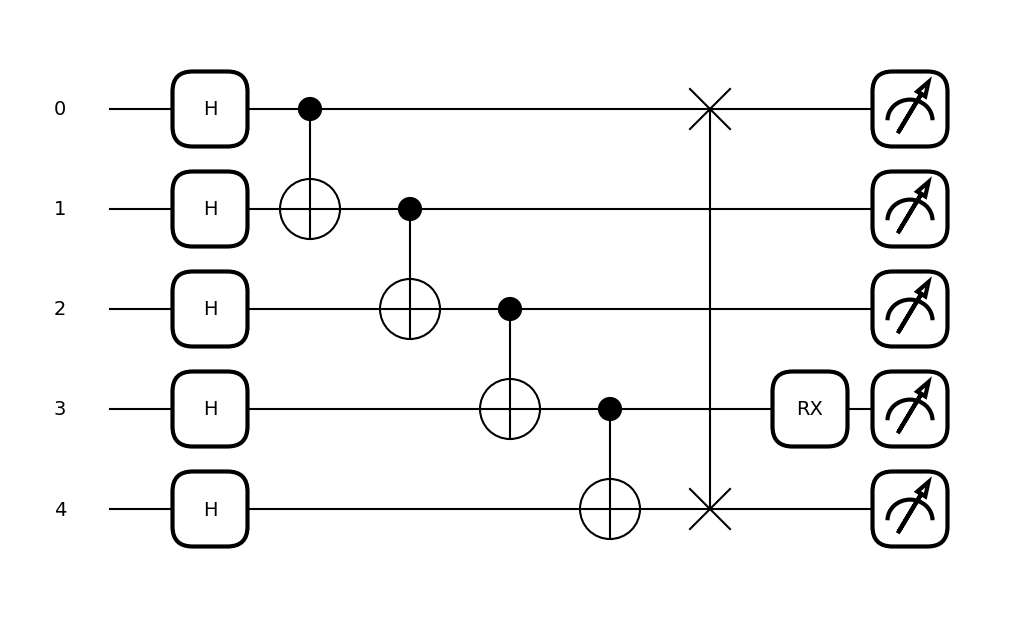

In [7]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt;

dev1 = qml.device("default.qubit",wires = 5)

@qml.qnode(dev1)
def circuit1():
    
    for i in range(5):
        qml.Hadamard(wires=i)

    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[3,4])

    qml.SWAP(wires=[0,4])

    qml.RX(np.pi/2, wires=3)

    return qml.state()


print(qml.draw(circuit1)())
print("\n")
print(circuit1())
print("\n")
fig, ax = qml.draw_mpl(circuit1)()
plt.show()


#### 1.2 Implement a second circuit with a framework of your choice:       
a)Apply a Hadmard gate to the first qubit.            
b)rotate the second qubit by pi/3 around X.                      
c)Apply Hadamard gate to the third and fourth qubit.                    
d)Perform a swap test between the states of the first and second qubit |q1 q2> and the third and fourth qubit |q3 q4>.          

0: ──H────────╭SWAP──H────┤  Probs
1: ──RX(1.05)─│─────╭SWAP─┤       
2: ──H────────├SWAP─│─────┤       
3: ──H────────│─────├SWAP─┤       
4: ──H────────╰●────╰●────┤       


[1. 0.]




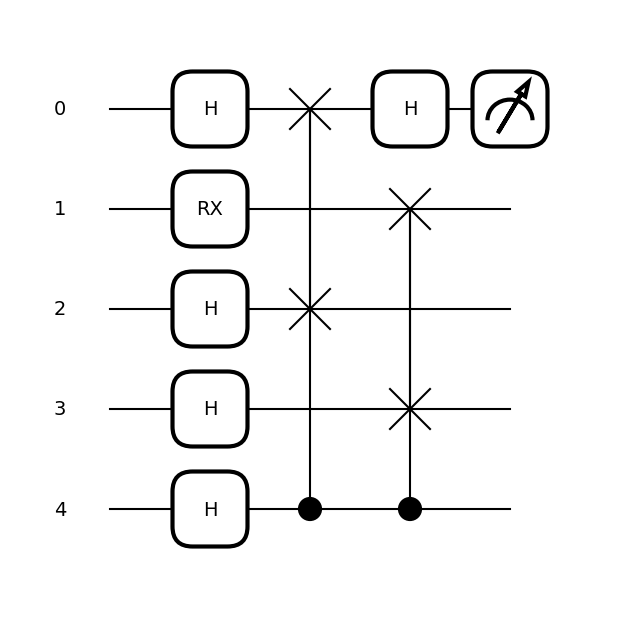

In [8]:
dev2 = qml.device("default.qubit",wires = 5)

@qml.qnode(dev2)
def circuit2():
    
    qml.Hadamard(wires=0)
    qml.RX(np.pi/3, wires=1)
    qml.Hadamard(wires=2)
    qml.Hadamard(wires=3)

    #Swap Test

    qml.Hadamard(wires=4)

    qml.CSWAP(wires=[4,0,2])
    qml.CSWAP(wires=[4,1,3])

    qml.Hadamard(wires=0)

    return qml.probs(wires=0)


print(qml.draw(circuit2)())
print("\n")
print(circuit2())
print("\n")
fig2, ax2 = qml.draw_mpl(circuit2)()
plt.show()